### Projektziel (Kurzbeschreibung)

In diesem Projekt wird ein Marketing-Kampagnendatensatz analysiert. Ziel ist es, (1) das Antwortverhalten auf Kampagnen zu verstehen und (2) Kundensegmente zu identifizieren, um daraus konkrete Marketing-Empfehlungen abzuleiten. Dazu werden Daten bereinigt, explorativ analysiert, Features abgeleitet, ein Klassifikationsmodell für `Antwort_Letzte_Kampagne` trainiert und eine Clusteranalyse durchgeführt.

# Clusteranalyse


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
# Datensatz in Erste Teile vorbereitet laden Überblick
df = pd.read_csv('Marktkampagne_V2.csv')
df.head(10)

,ID,Geburtsjahr,Alter,Einkommen,Bildungsniveau,Familienstand,Kinder_zu_Hause,Teenager_zu_Hause,Gesamt_Kinder,Datum_Kunde,...,Anzahl_Webkäufe,Anzahl_WebBesuche_Monat,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne,Beschwerde,Kundenbindungsdauer
0,5524,1967,59,58138.0,Hochschulabschluss,Ledig,0,0,0,2022-09-04,...,8,7,0,0,0,0,0,1,0,1243
1,2174,1964,62,46344.0,Hochschulabschluss,Ledig,1,1,2,2024-03-08,...,1,5,0,0,0,0,0,0,0,692
2,4141,1975,51,71613.0,Hochschulabschluss,Zusammenlebend,0,0,0,2023-08-21,...,8,4,0,0,0,0,0,0,0,892
3,6182,1994,32,26646.0,Hochschulabschluss,Zusammenlebend,1,0,1,2024-02-10,...,2,6,0,0,0,0,0,0,0,719
4,5324,1991,35,58293.0,Doktor,Verheiratet,1,0,1,2024-01-19,...,5,5,0,0,0,0,0,0,0,741
5,7446,1977,49,62513.0,Master,Zusammenlebend,0,1,1,2023-09-09,...,6,6,0,0,0,0,0,0,0,873
6,965,1981,45,55635.0,Hochschulabschluss,Geschieden,0,1,1,2022-11-13,...,7,6,0,0,0,0,0,0,0,1173
7,6177,1995,31,33454.0,Doktor,Verheiratet,1,0,1,2023-05-08,...,4,8,0,0,0,0,0,0,0,997
8,4855,1984,42,30351.0,Doktor,Zusammenlebend,1,0,1,2023-06-06,...,3,9,0,0,0,0,0,1,0,968
9,5899,1960,66,5648.0,Doktor,Zusammenlebend,1,1,2,2024-03-13,...,1,20,0,0,1,0,0,0,0,687


In [3]:
df.columns

Index(['ID', 'Geburtsjahr', 'Alter', 'Einkommen', 'Bildungsniveau',
       'Familienstand', 'Kinder_zu_Hause', 'Teenager_zu_Hause',
       'Gesamt_Kinder', 'Datum_Kunde', 'Letzter_Kauf_Tage',
       'Kundenbindungsdauer_Jahre', 'Ausgaben_Wein', 'Ausgaben_Fleisch',
       'Ausgaben_Obst', 'Ausgaben_Fisch', 'Ausgaben_Süßigkeiten',
       'Ausgaben_Gold', 'Ausgaben_pro_Jahr', 'Gesamt_Ausgaben', 'Wein_Anteil',
       'Wein_Anteil_Prozent', 'Anzahl_Rabattkäufe', 'Anzahl_Katalogkäufe',
       'Anzahl_Ladeneinkäufe', 'Anzahl_Webkäufe', 'Anzahl_WebBesuche_Monat',
       'Kampagne_1_Akzeptiert', 'Kampagne_2_Akzeptiert',
       'Kampagne_3_Akzeptiert', 'Kampagne_4_Akzeptiert',
       'Kampagne_5_Akzeptiert', 'Antwort_Letzte_Kampagne', 'Beschwerde',
       'Kundenbindungsdauer'],
      dtype='object')

In [4]:
df['Datum_Kunde'] = pd.to_datetime(df['Datum_Kunde'], errors='coerce')


In [5]:
df['Kundenbindungsdauer'] = (
    df['Kundenbindungsdauer']
    .astype(str)
    .str.extract('(\d+)')   # nur Zahlen behalten
    .astype(float)
)

<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\hberh\AppData\Local\Temp\ipykernel_32512\1970411329.py:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  .str.extract('(\d+)')   # nur Zahlen behalten


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2035 entries, 0 to 2034
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ID                         2035 non-null   int64         
 1   Geburtsjahr                2035 non-null   int64         
 2   Alter                      2035 non-null   int64         
 3   Einkommen                  2035 non-null   float64       
 4   Bildungsniveau             2035 non-null   object        
 5   Familienstand              2035 non-null   object        
 6   Kinder_zu_Hause            2035 non-null   int64         
 7   Teenager_zu_Hause          2035 non-null   int64         
 8   Gesamt_Kinder              2035 non-null   int64         
 9   Datum_Kunde                2035 non-null   datetime64[ns]
 10  Letzter_Kauf_Tage          2035 non-null   int64         
 11  Kundenbindungsdauer_Jahre  2035 non-null   float64       
 12  Ausgab

In [7]:
df.columns

Index(['ID', 'Geburtsjahr', 'Alter', 'Einkommen', 'Bildungsniveau',
       'Familienstand', 'Kinder_zu_Hause', 'Teenager_zu_Hause',
       'Gesamt_Kinder', 'Datum_Kunde', 'Letzter_Kauf_Tage',
       'Kundenbindungsdauer_Jahre', 'Ausgaben_Wein', 'Ausgaben_Fleisch',
       'Ausgaben_Obst', 'Ausgaben_Fisch', 'Ausgaben_Süßigkeiten',
       'Ausgaben_Gold', 'Ausgaben_pro_Jahr', 'Gesamt_Ausgaben', 'Wein_Anteil',
       'Wein_Anteil_Prozent', 'Anzahl_Rabattkäufe', 'Anzahl_Katalogkäufe',
       'Anzahl_Ladeneinkäufe', 'Anzahl_Webkäufe', 'Anzahl_WebBesuche_Monat',
       'Kampagne_1_Akzeptiert', 'Kampagne_2_Akzeptiert',
       'Kampagne_3_Akzeptiert', 'Kampagne_4_Akzeptiert',
       'Kampagne_5_Akzeptiert', 'Antwort_Letzte_Kampagne', 'Beschwerde',
       'Kundenbindungsdauer'],
      dtype='object')

In [8]:
df_Segment = df[['Alter', 'Einkommen', 'Gesamt_Kinder', 'Bildungsniveau',
                 'Familienstand', 'Kundenbindungsdauer',
                 'Letzter_Kauf_Tage', 'Kundenbindungsdauer_Jahre', 'Ausgaben_Wein',
                 'Ausgaben_Fleisch', 'Ausgaben_Obst', 'Ausgaben_Fisch',
                 'Ausgaben_Süßigkeiten', 'Ausgaben_Gold', 'Ausgaben_pro_Jahr',
                 'Gesamt_Ausgaben', 'Wein_Anteil', 'Anzahl_Rabattkäufe',
                 'Anzahl_Katalogkäufe', 'Anzahl_Ladeneinkäufe', 'Anzahl_Webkäufe',
                 'Anzahl_WebBesuche_Monat']]

In [9]:
# Numerische Features
numerical_features = [
                 'Alter', 'Einkommen', 'Gesamt_Kinder', 'Kundenbindungsdauer',
                 'Letzter_Kauf_Tage', 'Kundenbindungsdauer_Jahre', 'Ausgaben_Wein',
                 'Ausgaben_Fleisch', 'Ausgaben_Obst', 'Ausgaben_Fisch',
                 'Ausgaben_Süßigkeiten', 'Ausgaben_Gold', 'Ausgaben_pro_Jahr',
                 'Gesamt_Ausgaben', 'Wein_Anteil', 'Anzahl_Rabattkäufe',
                 'Anzahl_Katalogkäufe', 'Anzahl_Ladeneinkäufe', 'Anzahl_Webkäufe',
                 'Anzahl_WebBesuche_Monat'
]

# Kategorische Features
categorical_features = ['Bildungsniveau', 'Familienstand']

In [10]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

In [11]:
# Transformation
X_scaled = preprocessor.fit_transform(df_Segment)

# Feature-Namen
num_features = numerical_features

cat_features = preprocessor.named_transformers_['cat'] \
    .get_feature_names_out(categorical_features)

feature_names = list(num_features) + list(cat_features)

# DataFrame erstellen
df_scaled = pd.DataFrame(
    X_scaled.toarray() if hasattr(X_scaled, "toarray") else X_scaled,
    columns=feature_names,
    index=df_Segment.index
)


In [12]:

# scaler = StandardScaler()
# df_scaled = scaler.fit_transform(df_Segment)

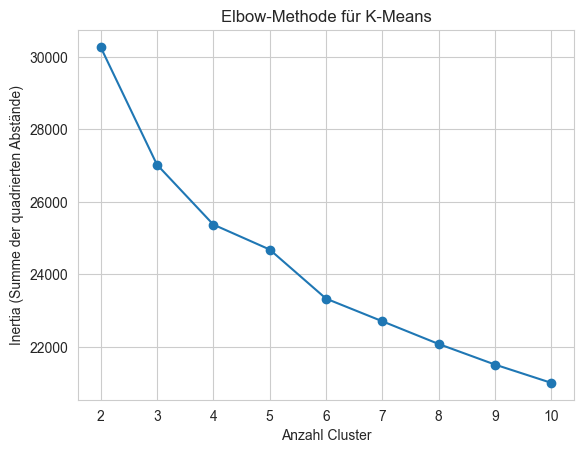

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(df_scaled, km.labels_))


plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Anzahl Cluster")
plt.ylabel("Inertia (Summe der quadrierten Abstände)")
plt.title("Elbow-Methode für K-Means")
plt.show()

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(df_scaled, km.labels_))

# Ergebnisse in einer Tabelle anzeigen
import pandas as pd
results = pd.DataFrame({
    'Anzahl_Cluster': range(2, 11),
    'Inertia': inertia,
    'Silhouette': silhouette
})
results


,Anzahl_Cluster,Inertia,Silhouette
0,2,30275.763311,0.286977
1,3,27030.194514,0.192249
2,4,25376.870893,0.130937
3,5,24688.015669,0.128431
4,6,23334.060697,0.114211
5,7,22708.847530,0.109194
6,8,22081.502602,0.111747
7,9,21513.778872,0.107360
8,10,21009.047586,0.093129


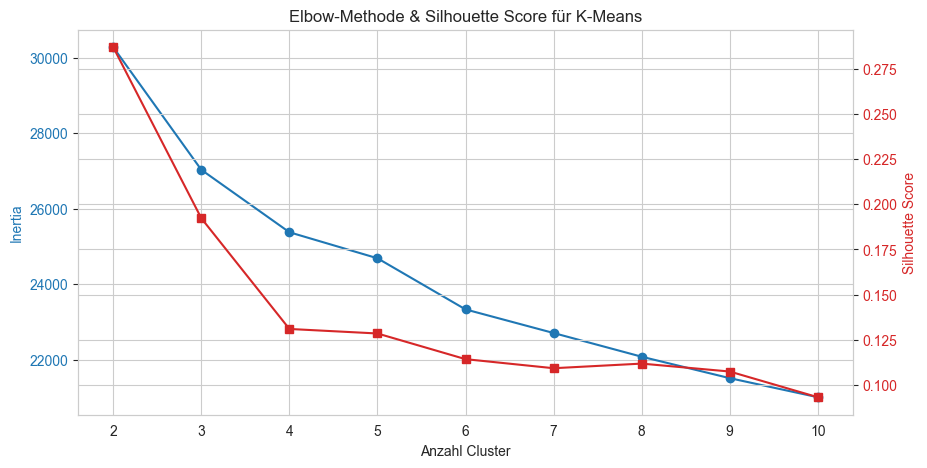

In [15]:
fig, ax1 = plt.subplots(figsize=(10,5))

color = 'tab:blue'
ax1.set_xlabel('Anzahl Cluster')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(range(2,11), inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # zweites y-Achsen für Silhouette
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(range(2,11), silhouette, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow-Methode & Silhouette Score für K-Means')
plt.show()


In [16]:

best_idx = results['Silhouette'].idxmax()

best_k_silhouette = results.loc[best_idx, 'Anzahl_Cluster']
best_silhouette_score = results.loc[best_idx, 'Silhouette']

print(
    f"Bestes k nach Silhouette: {best_k_silhouette} "
    f"(Score={best_silhouette_score:.3f})"
)


Bestes k nach Silhouette: 2 (Score=0.287)


In [17]:
import numpy as np

inertia_vals = results['Inertia'].values

diff = np.diff(inertia_vals)
diff2 = np.diff(diff)

elbow_idx = np.argmin(diff2) + 1
best_k_inertia = results.loc[elbow_idx, 'Anzahl_Cluster']

print(f"Bestes k nach Elbow (Inertia): {best_k_inertia}")


Bestes k nach Elbow (Inertia): 5


k = 3 ist eine sehr gute, vernünftige Wahl 
Das ist genau der gesunde Kompromiss zwischen Struktur und Interpretierbarkeit.

In [18]:
kmeans = KMeans(n_clusters=3, random_state =42)
df_Segment['Cluster'] = kmeans.fit_predict(df_scaled)

C:\Users\hberh\AppData\Local\Temp\ipykernel_32512\273871619.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Segment['Cluster'] = kmeans.fit_predict(df_scaled)


In [19]:
df['Cluster'] = df_Segment['Cluster'] 

In [20]:
df.head()

,ID,Geburtsjahr,Alter,Einkommen,Bildungsniveau,Familienstand,Kinder_zu_Hause,Teenager_zu_Hause,Gesamt_Kinder,Datum_Kunde,...,Anzahl_WebBesuche_Monat,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne,Beschwerde,Kundenbindungsdauer,Cluster
0,5524,1967,59,58138.0,Hochschulabschluss,Ledig,0,0,0,2022-09-04,...,7,0,0,0,0,0,1,0,1243.0,0
1,2174,1964,62,46344.0,Hochschulabschluss,Ledig,1,1,2,2024-03-08,...,5,0,0,0,0,0,0,0,692.0,2
2,4141,1975,51,71613.0,Hochschulabschluss,Zusammenlebend,0,0,0,2023-08-21,...,4,0,0,0,0,0,0,0,892.0,0
3,6182,1994,32,26646.0,Hochschulabschluss,Zusammenlebend,1,0,1,2024-02-10,...,6,0,0,0,0,0,0,0,719.0,2
4,5324,1991,35,58293.0,Doktor,Verheiratet,1,0,1,2024-01-19,...,5,0,0,0,0,0,0,0,741.0,1


In [21]:
cluster_summary = (
    df_Segment
    .groupby('Cluster')
    .mean(numeric_only=True)
)

cluster_summary


,Alter,Einkommen,Gesamt_Kinder,Kundenbindungsdauer,Letzter_Kauf_Tage,Kundenbindungsdauer_Jahre,Ausgaben_Wein,Ausgaben_Fleisch,Ausgaben_Obst,Ausgaben_Fisch,Ausgaben_Süßigkeiten,Ausgaben_Gold,Ausgaben_pro_Jahr,Gesamt_Ausgaben,Wein_Anteil,Anzahl_Rabattkäufe,Anzahl_Katalogkäufe,Anzahl_Ladeneinkäufe,Anzahl_Webkäufe,Anzahl_WebBesuche_Monat
Cluster,,,,,,,,,,,,,,,,,,,,
0,47.919929,75711.999438,0.265125,936.770463,49.585409,2.564738,605.535587,447.738434,67.891459,98.298932,70.695730,77.564057,553.382429,1367.724199,0.427407,1.400356,5.941281,8.339858,5.352313,2.939502
1,50.839187,56381.261426,1.210721,1003.606285,48.060998,2.747724,445.377079,126.844732,19.340111,25.406654,19.855823,58.014787,260.015143,694.839187,0.622026,3.955638,2.885397,7.502773,6.338262,6.040665
2,44.506438,35275.953718,1.216738,887.413090,49.506438,2.429605,39.326180,22.767167,5.402361,7.681330,5.365880,15.026824,40.981313,95.569742,0.383232,1.939914,0.551502,3.225322,2.045064,6.316524


In [22]:
cluster_summary [['Alter', 'Einkommen', 'Gesamt_Kinder', 
       'Letzter_Kauf_Tage', 'Kundenbindungsdauer_Jahre', 'Gesamt_Ausgaben','Ausgaben_pro_Jahr',
       'Anzahl_Katalogkäufe', 'Anzahl_Ladeneinkäufe', 'Anzahl_Webkäufe','Anzahl_WebBesuche_Monat']]

,Alter,Einkommen,Gesamt_Kinder,Letzter_Kauf_Tage,Kundenbindungsdauer_Jahre,Gesamt_Ausgaben,Ausgaben_pro_Jahr,Anzahl_Katalogkäufe,Anzahl_Ladeneinkäufe,Anzahl_Webkäufe,Anzahl_WebBesuche_Monat
Cluster,,,,,,,,,,,
0,47.919929,75711.999438,0.265125,49.585409,2.564738,1367.724199,553.382429,5.941281,8.339858,5.352313,2.939502
1,50.839187,56381.261426,1.210721,48.060998,2.747724,694.839187,260.015143,2.885397,7.502773,6.338262,6.040665
2,44.506438,35275.953718,1.216738,49.506438,2.429605,95.569742,40.981313,0.551502,3.225322,2.045064,6.316524


In [23]:
palette = {
    0: "#0A1AFF",  # Blau
    1: "#FFEA00",  # Gold
    2: "#FF9A35"   # Orange
}

In [24]:
df_Segment['Cluster'].value_counts()


Cluster
2    932
0    562
1    541
Name: count, dtype: int64

In [25]:
(df_Segment['Cluster'].value_counts(normalize=True) * 100).round(2)


Cluster
2    45.80
0    27.62
1    26.58
Name: proportion, dtype: float64

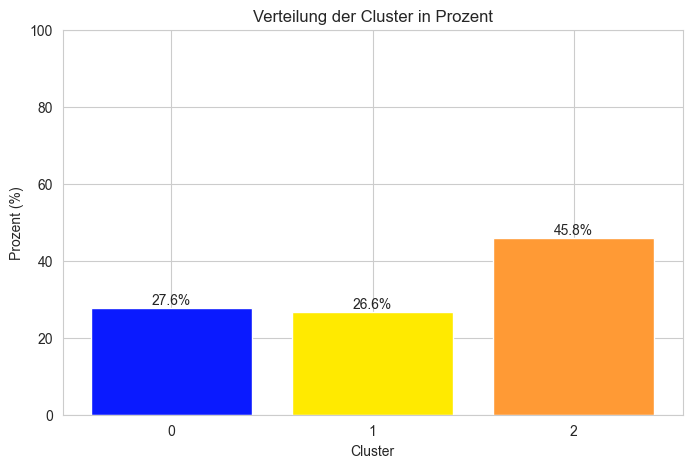

In [26]:
import matplotlib.pyplot as plt

# Cluster-Prozente
cluster_percent = (df_Segment['Cluster'].value_counts(normalize=True).sort_index() * 100)

# Farben nach Cluster-Nummer
colors = [palette[c] for c in cluster_percent.index]

# Barplot
plt.figure(figsize=(8,5))
bars = plt.bar(cluster_percent.index.astype(str), cluster_percent.values, color=colors)

plt.xlabel("Cluster")
plt.ylabel("Prozent (%)")
plt.title("Verteilung der Cluster in Prozent")
plt.ylim(0, 100)

# Prozentwerte über Balken
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{height:.1f}%", ha='center')

plt.show()


In [27]:
df.head()

,ID,Geburtsjahr,Alter,Einkommen,Bildungsniveau,Familienstand,Kinder_zu_Hause,Teenager_zu_Hause,Gesamt_Kinder,Datum_Kunde,...,Anzahl_WebBesuche_Monat,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne,Beschwerde,Kundenbindungsdauer,Cluster
0,5524,1967,59,58138.0,Hochschulabschluss,Ledig,0,0,0,2022-09-04,...,7,0,0,0,0,0,1,0,1243.0,0
1,2174,1964,62,46344.0,Hochschulabschluss,Ledig,1,1,2,2024-03-08,...,5,0,0,0,0,0,0,0,692.0,2
2,4141,1975,51,71613.0,Hochschulabschluss,Zusammenlebend,0,0,0,2023-08-21,...,4,0,0,0,0,0,0,0,892.0,0
3,6182,1994,32,26646.0,Hochschulabschluss,Zusammenlebend,1,0,1,2024-02-10,...,6,0,0,0,0,0,0,0,719.0,2
4,5324,1991,35,58293.0,Doktor,Verheiratet,1,0,1,2024-01-19,...,5,0,0,0,0,0,0,0,741.0,1


In [28]:
for col in categorical_features:
    print(f"\nSpalte: {col}")
    sorted_counts = df_Segment.groupby('Cluster')[col] \
        .value_counts(normalize=True) \
        .mul(100) \
        .groupby(level=0, group_keys=False) \
        .apply(lambda x: x.sort_values(ascending=False))
    print(sorted_counts)




Spalte: Bildungsniveau
Cluster  Bildungsniveau       
0        Hochschulabschluss       56.761566
         Doktor                   19.750890
         Master                   14.234875
         Zweiter Studienzyklus     9.074733
         Grundbildung              0.177936
1        Hochschulabschluss       46.580407
         Doktor                   28.650647
         Master                   19.223660
         Zweiter Studienzyklus     5.360444
         Grundbildung              0.184843
2        Hochschulabschluss       48.605150
         Doktor                   18.669528
         Master                   16.309013
         Zweiter Studienzyklus    11.373391
         Grundbildung              5.042918
Name: proportion, dtype: float64

Spalte: Familienstand
Cluster  Familienstand 
0        Verheiratet       36.654804
         Zusammenlebend    25.444840
         Ledig             23.665480
         Geschieden         9.786477
         Verwitwet          4.448399
1        Verheiratet

In [29]:
palette2 = {
      'Hochschulabschluss'   : "#081299" ,    
         'Doktor'    :       "#0A1AFF" ,           
         'Master'    : "#9DA3FB",            
         'Zweiter Studienzyklus'  : "#FFEA00",   
         'Grundbildung'  :            "#FFAA00"     
}

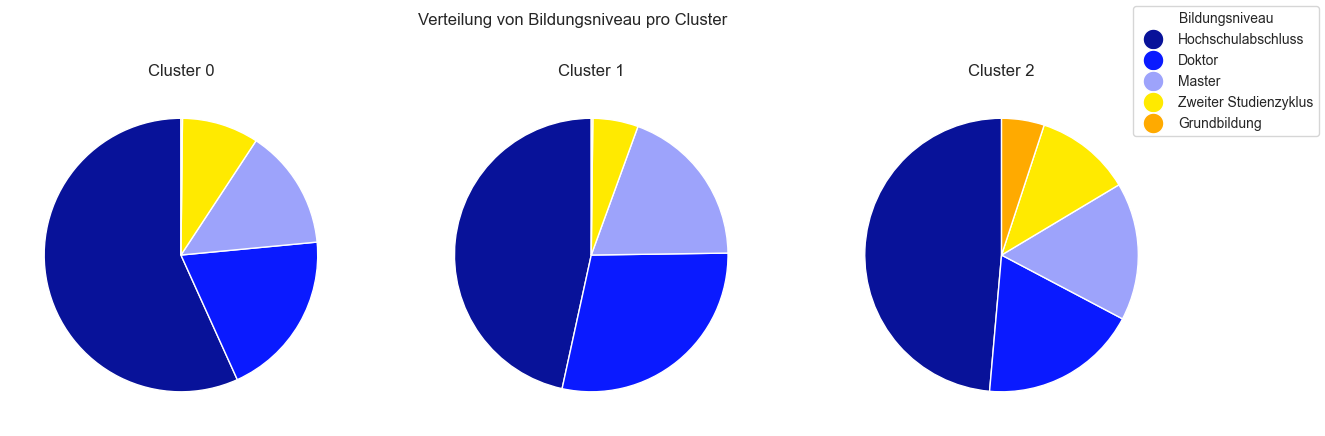

In [30]:
import matplotlib.pyplot as plt

# Beispiel: eine kategoriale Spalte
col = categorical_features[0]

# Cluster-Liste
clusters = sorted(df_Segment['Cluster'].unique())

# Pie-Charts nebeneinander
fig, axes = plt.subplots(1, len(clusters), figsize=(15,5))

for i, cluster in enumerate(clusters):
    data = df_Segment[df_Segment['Cluster'] == cluster][col].value_counts()
    
    # Farben zuordnen: falls Kategorie numerisch und mit 0,1,2 übereinstimmt
    colors = [palette2.get(x, "#CCCCCC") for x in data.index]  # default grau falls nicht in Palette
    
    axes[i].pie(data, colors=colors, startangle=90, wedgeprops={'edgecolor':'white'})
    axes[i].set_title(f'Cluster {cluster}')
# Gemeinsame Legende für alle Pies
fig.legend(
    handles=[plt.Line2D([0], [0], marker='o', color='w', label=k, markerfacecolor=v, markersize=15) 
             for k,v in palette2.items()],
    loc='upper right',
    title=col
)

plt.suptitle(f'Verteilung von {col} pro Cluster')
plt.show()


In [31]:
df['Familienstand'].value_counts()

Familienstand
Verheiratet       788
Zusammenlebend    516
Ledig             449
Geschieden        212
Verwitwet          70
Name: count, dtype: int64

In [32]:
palette3 = {
    'Verheiratet'      : "#6D0388",  # Blau
    'Zusammenlebend'   : "#0A1AFF",  # Hellblau
    'Ledig'            : "#9DA3FB",  # Lila-Blau
    'Geschieden'       : "#FFEA00",  # Gelb
    'Verwitwet'        : "#FFAA00"   # Orange
}

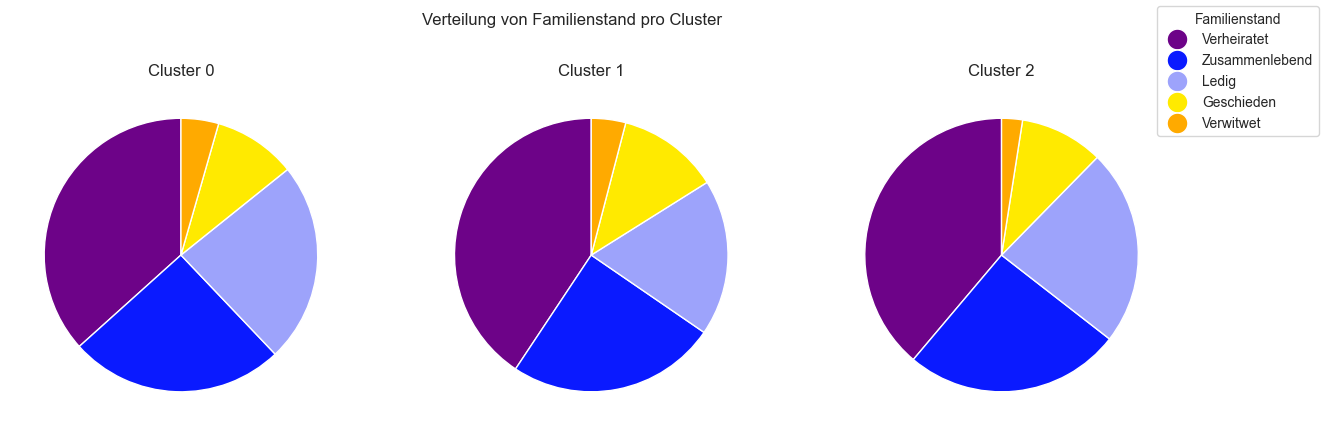

In [33]:
# Beispiel: eine kategoriale Spalte
col = categorical_features[1]

# Cluster-Liste
clusters = sorted(df_Segment['Cluster'].unique())

# Pie-Charts nebeneinander
fig, axes = plt.subplots(1, len(clusters), figsize=(15,5))

for i, cluster in enumerate(clusters):
    data = df_Segment[df_Segment['Cluster'] == cluster][col].value_counts()
    
    # Farben zuordnen: falls Kategorie numerisch und mit 0,1,2 übereinstimmt
    colors = [palette3.get(x, "#CCCCCC") for x in data.index]  # default grau falls nicht in Palette
    
    axes[i].pie(data, colors=colors, startangle=90, wedgeprops={'edgecolor':'white'})
    axes[i].set_title(f'Cluster {cluster}')
# Gemeinsame Legende für alle Pies
fig.legend(
    handles=[plt.Line2D([1], [1], marker='o', color='w', label=k, markerfacecolor=v, markersize=15) 
             for k,v in palette3.items()],
    loc='upper right',
    title=col
)

plt.suptitle(f'Verteilung von {col} pro Cluster')
plt.show()

### PCA = Principal Component Analysis (Hauptkomponentenanalyse)

Zweck: Daten vereinfachen, ohne zu viel Information zu verlieren
PCA = Daten vereinfachen / komprimieren

Clustering = ähnliche Kunden gruppieren

PCA + Clustering = klarere Gruppen, weniger Rauschen, leichter zu visualisieren

C:\Users\hberh\AppData\Local\Temp\ipykernel_32512\1129722494.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Segment['PCA1'] = X_pca[:,0]
C:\Users\hberh\AppData\Local\Temp\ipykernel_32512\1129722494.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Segment['PCA2'] = X_pca[:,1]


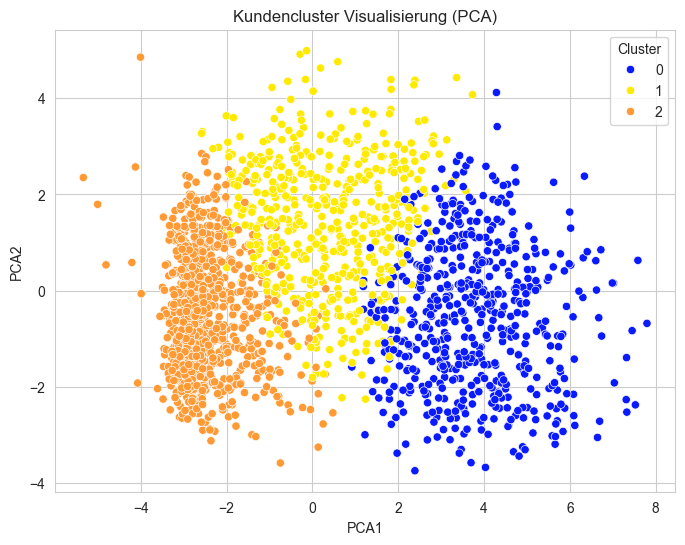

In [34]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

df_Segment['PCA1'] = X_pca[:,0]
df_Segment['PCA2'] = X_pca[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_Segment, x='PCA1', y='PCA2', hue='Cluster', palette= palette)
plt.title("Kundencluster Visualisierung (PCA)")
plt.show()


C:\Users\hberh\AppData\Local\Temp\ipykernel_32512\3513700174.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Segment['Cluster'] = kmeans.fit_predict(df_scaled)
C:\Users\hberh\AppData\Local\Temp\ipykernel_32512\3513700174.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Segment['PCA1'] = pca_result[:,0]
C:\Users\hberh\AppData\Local\Temp\ipykernel_32512\3513700174.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

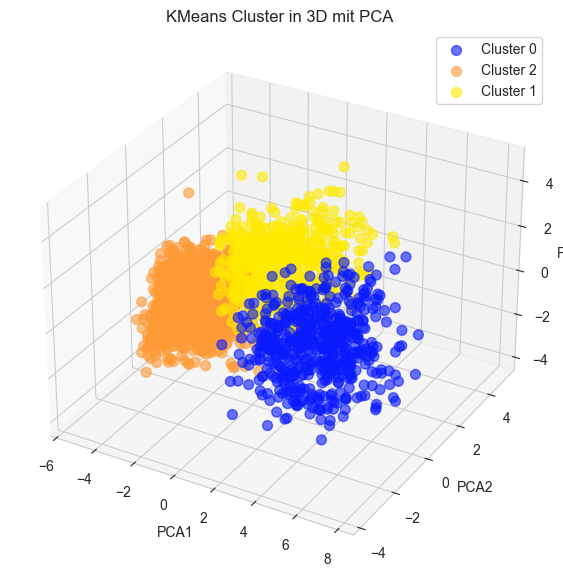

In [35]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1️⃣ KMeans Cluster
kmeans = KMeans(n_clusters=3, random_state=42)
df_Segment['Cluster'] = kmeans.fit_predict(df_scaled)

# 2️⃣ PCA auf 3 Dimensionen
pca = PCA(n_components=3)
pca_result = pca.fit_transform(df_scaled)

df_Segment['PCA1'] = pca_result[:,0]
df_Segment['PCA2'] = pca_result[:,1]
df_Segment['PCA3'] = pca_result[:,2]

# 3️⃣ 3D-Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
colors = palette

for cluster in df_Segment['Cluster'].unique():
    subset = df_Segment[df_Segment['Cluster'] == cluster]
    ax.scatter(subset['PCA1'], subset['PCA2'], subset['PCA3'],
               s=50, c=colors[cluster], label=f'Cluster {cluster}', alpha=0.6)

ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('KMeans Cluster in 3D mit PCA')
ax.legend()
plt.show()


### Clusteranalyse Reaktion auf Kampagne

In [36]:
kampagnen = [
    'Kampagne_1_Akzeptiert',
    'Kampagne_2_Akzeptiert',
    'Kampagne_3_Akzeptiert',
    'Kampagne_4_Akzeptiert',
    'Kampagne_5_Akzeptiert',
    'Antwort_Letzte_Kampagne'
]

akzeptanz_df = (
    df
    .groupby('Cluster')[kampagnen]
    .sum()
    .reset_index()
    .melt(id_vars='Cluster', var_name='Kampagne', value_name='Anzahl_Akzeptanz')
)

akzeptanz_df


,Cluster,Kampagne,Anzahl_Akzeptanz
0,0,Kampagne_1_Akzeptiert,112
1,1,Kampagne_1_Akzeptiert,21
2,2,Kampagne_1_Akzeptiert,1
3,0,Kampagne_2_Akzeptiert,15
4,1,Kampagne_2_Akzeptiert,10
5,2,Kampagne_2_Akzeptiert,1
6,0,Kampagne_3_Akzeptiert,43
7,1,Kampagne_3_Akzeptiert,40
8,2,Kampagne_3_Akzeptiert,64
9,0,Kampagne_4_Akzeptiert,69


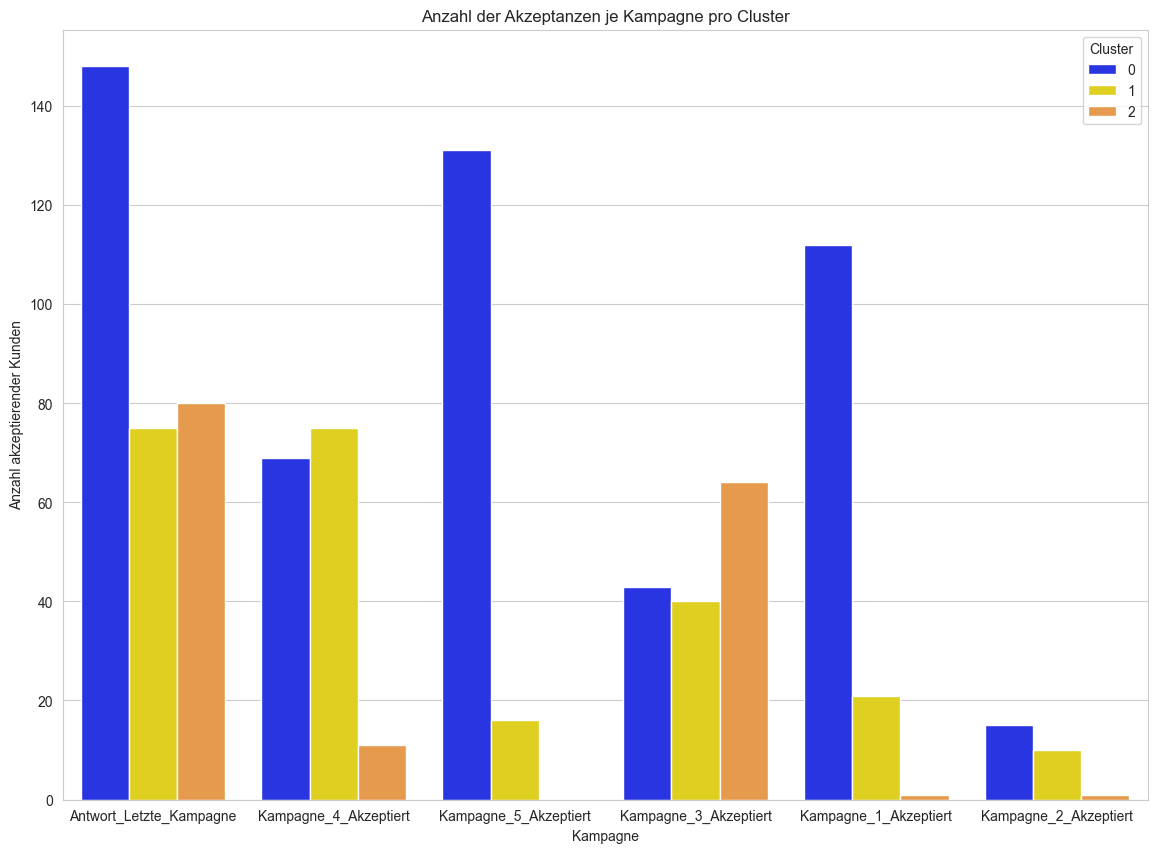

In [37]:

# Reihenfolge der Kampagnen nach Gesamt-Akzeptanz
order = (
    akzeptanz_df
    .groupby('Kampagne')['Anzahl_Akzeptanz']
    .sum()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(14, 10))
sns.barplot(
    data=akzeptanz_df,
    x='Kampagne',
    y='Anzahl_Akzeptanz',
    hue='Cluster',
    order=order,
    palette=palette
)

plt.title("Anzahl der Akzeptanzen je Kampagne pro Cluster")
plt.ylabel("Anzahl akzeptierender Kunden")
plt.xlabel("Kampagne")
plt.legend(title="Cluster")
plt.show()


### Clusteranalyse Anzahl_Rabattkäufe

In [38]:
rabatt_df = (
    df
    .groupby('Cluster')['Anzahl_Rabattkäufe']
    .sum()
    .reset_index()
)
rabatt_df

,Cluster,Anzahl_Rabattkäufe
0,0,787
1,1,2140
2,2,1808


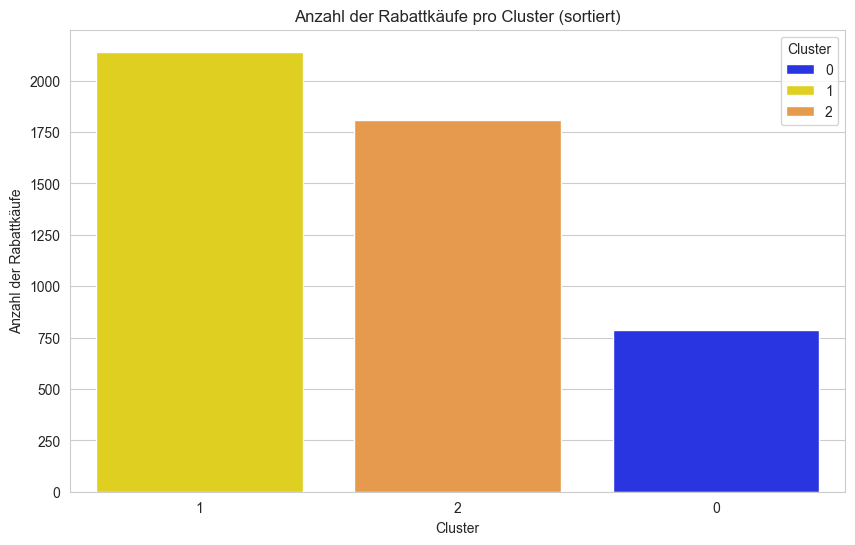

In [39]:
order = (
    rabatt_df
    .sort_values('Anzahl_Rabattkäufe', ascending=False)['Cluster']
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=rabatt_df,
    x='Cluster',
    y='Anzahl_Rabattkäufe',
    order=order,
    palette= palette,
     hue='Cluster'
)

plt.title("Anzahl der Rabattkäufe pro Cluster (sortiert)")
plt.xlabel("Cluster")
plt.ylabel("Anzahl der Rabattkäufe")
plt.show()


In [40]:
df.columns

Index(['ID', 'Geburtsjahr', 'Alter', 'Einkommen', 'Bildungsniveau',
       'Familienstand', 'Kinder_zu_Hause', 'Teenager_zu_Hause',
       'Gesamt_Kinder', 'Datum_Kunde', 'Letzter_Kauf_Tage',
       'Kundenbindungsdauer_Jahre', 'Ausgaben_Wein', 'Ausgaben_Fleisch',
       'Ausgaben_Obst', 'Ausgaben_Fisch', 'Ausgaben_Süßigkeiten',
       'Ausgaben_Gold', 'Ausgaben_pro_Jahr', 'Gesamt_Ausgaben', 'Wein_Anteil',
       'Wein_Anteil_Prozent', 'Anzahl_Rabattkäufe', 'Anzahl_Katalogkäufe',
       'Anzahl_Ladeneinkäufe', 'Anzahl_Webkäufe', 'Anzahl_WebBesuche_Monat',
       'Kampagne_1_Akzeptiert', 'Kampagne_2_Akzeptiert',
       'Kampagne_3_Akzeptiert', 'Kampagne_4_Akzeptiert',
       'Kampagne_5_Akzeptiert', 'Antwort_Letzte_Kampagne', 'Beschwerde',
       'Kundenbindungsdauer', 'Cluster'],
      dtype='object')

### Clusteranalyse Gesamt_Ausgaben

In [41]:
gesamt_df = (
    df
    .groupby('Cluster')[ 'Gesamt_Ausgaben']
    .sum()
    .reset_index()
)

gesamt_df


,Cluster,Gesamt_Ausgaben
0,0,768661
1,1,375908
2,2,89071


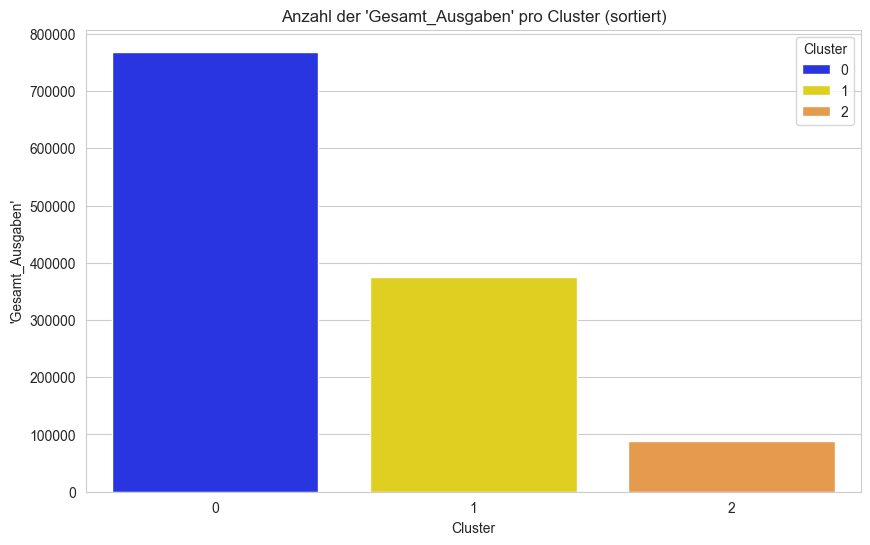

In [42]:
order = (
    gesamt_df
    .sort_values('Gesamt_Ausgaben', ascending=False)['Cluster']
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=gesamt_df,
    x='Cluster',
    y='Gesamt_Ausgaben',
    order=order,
    palette=palette,
     hue='Cluster'
)

plt.title("Anzahl der 'Gesamt_Ausgaben' pro Cluster (sortiert)")
plt.xlabel("Cluster")
plt.ylabel("'Gesamt_Ausgaben'")
plt.show()


### Clusteranalyse Produkt_Ausgaben

In [43]:
ausgaben_spalten = [
    'Ausgaben_Wein',
    'Ausgaben_Fleisch', 
    'Ausgaben_Obst', 
    'Ausgaben_Fisch',
    'Ausgaben_Süßigkeiten', 
    'Ausgaben_Gold'
]

ausgaben_df = (
    df
    .groupby('Cluster')[ausgaben_spalten]
    .sum()
    .reset_index()
)

ausgaben_df


,Cluster,Ausgaben_Wein,Ausgaben_Fleisch,Ausgaben_Obst,Ausgaben_Fisch,Ausgaben_Süßigkeiten,Ausgaben_Gold
0,0,340311,251629,38155,55244,39731,43591
1,1,240949,68623,10463,13745,10742,31386
2,2,36652,21219,5035,7159,5001,14005


In [44]:
ausgaben_long_df = ausgaben_df.melt(
    id_vars='Cluster',
    var_name='Kategorie',
    value_name='Ausgaben'
)

ausgaben_long_df


,Cluster,Kategorie,Ausgaben
0,0,Ausgaben_Wein,340311
1,1,Ausgaben_Wein,240949
2,2,Ausgaben_Wein,36652
3,0,Ausgaben_Fleisch,251629
4,1,Ausgaben_Fleisch,68623
5,2,Ausgaben_Fleisch,21219
6,0,Ausgaben_Obst,38155
7,1,Ausgaben_Obst,10463
8,2,Ausgaben_Obst,5035
9,0,Ausgaben_Fisch,55244


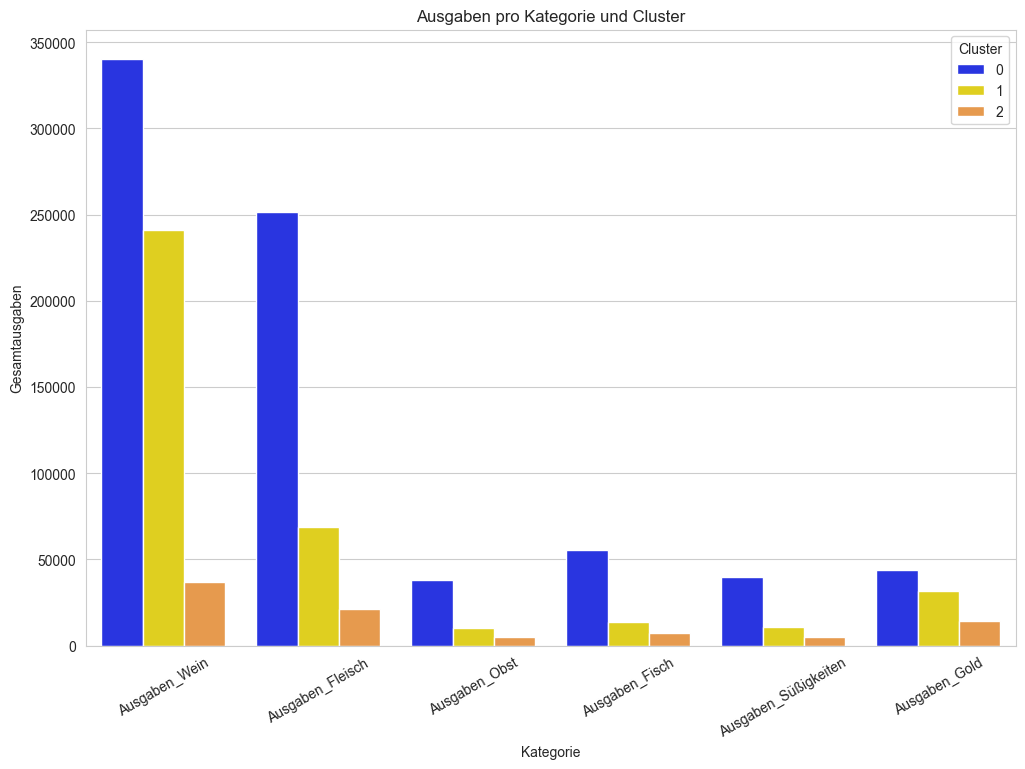

In [45]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=ausgaben_long_df,
    x='Kategorie',
    y='Ausgaben',
    hue='Cluster',
    palette=palette
)

plt.title("Ausgaben pro Kategorie und Cluster")
plt.xlabel("Kategorie")
plt.ylabel("Gesamtausgaben")
plt.xticks(rotation=30)
plt.show()

### Clusteranalyse  Verkaufverhältniss


In [46]:
Kauf_Verhaltnis = [
    'Anzahl_Katalogkäufe',
    'Anzahl_Ladeneinkäufe', 'Anzahl_Webkäufe'
]

df_Kauf_Verhaltnis= (
    df
    .groupby('Cluster')[Kauf_Verhaltnis]
    .sum()
    .reset_index()
    .melt(id_vars='Cluster', var_name='Kauf_Kanal', value_name='Anzahl_kauf_pro_kanal')
)

df_Kauf_Verhaltnis

,Cluster,Kauf_Kanal,Anzahl_kauf_pro_kanal
0,0,Anzahl_Katalogkäufe,3339
1,1,Anzahl_Katalogkäufe,1561
2,2,Anzahl_Katalogkäufe,514
3,0,Anzahl_Ladeneinkäufe,4687
4,1,Anzahl_Ladeneinkäufe,4059
5,2,Anzahl_Ladeneinkäufe,3006
6,0,Anzahl_Webkäufe,3008
7,1,Anzahl_Webkäufe,3429
8,2,Anzahl_Webkäufe,1906


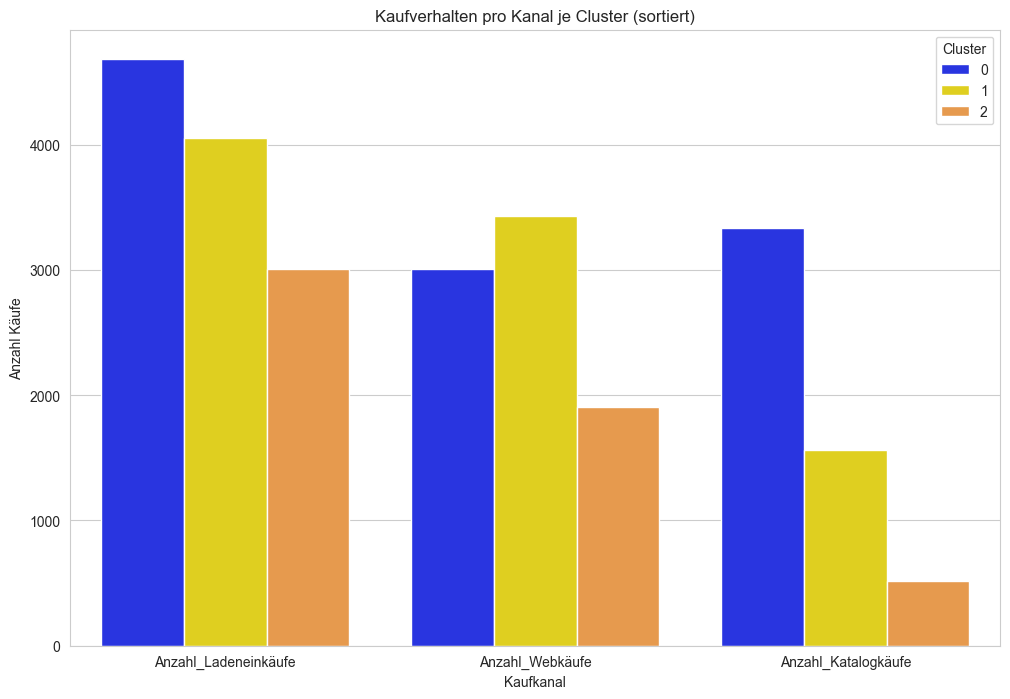

In [47]:
order = (
    df_Kauf_Verhaltnis
    .groupby('Kauf_Kanal')['Anzahl_kauf_pro_kanal']
    .sum()
    .sort_values(ascending=False)
    .index
)
plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_Kauf_Verhaltnis,
    x='Kauf_Kanal',
    y='Anzahl_kauf_pro_kanal',
    hue='Cluster',
    order=order,
    palette=palette
)

plt.title("Kaufverhalten pro Kanal je Cluster (sortiert)")
plt.xlabel("Kaufkanal")
plt.ylabel("Anzahl Käufe")
plt.legend(title="Cluster")
plt.show()

In [48]:
df.columns

Index(['ID', 'Geburtsjahr', 'Alter', 'Einkommen', 'Bildungsniveau',
       'Familienstand', 'Kinder_zu_Hause', 'Teenager_zu_Hause',
       'Gesamt_Kinder', 'Datum_Kunde', 'Letzter_Kauf_Tage',
       'Kundenbindungsdauer_Jahre', 'Ausgaben_Wein', 'Ausgaben_Fleisch',
       'Ausgaben_Obst', 'Ausgaben_Fisch', 'Ausgaben_Süßigkeiten',
       'Ausgaben_Gold', 'Ausgaben_pro_Jahr', 'Gesamt_Ausgaben', 'Wein_Anteil',
       'Wein_Anteil_Prozent', 'Anzahl_Rabattkäufe', 'Anzahl_Katalogkäufe',
       'Anzahl_Ladeneinkäufe', 'Anzahl_Webkäufe', 'Anzahl_WebBesuche_Monat',
       'Kampagne_1_Akzeptiert', 'Kampagne_2_Akzeptiert',
       'Kampagne_3_Akzeptiert', 'Kampagne_4_Akzeptiert',
       'Kampagne_5_Akzeptiert', 'Antwort_Letzte_Kampagne', 'Beschwerde',
       'Kundenbindungsdauer', 'Cluster'],
      dtype='object')